# Decifrando o Algoritmo: Análise Exploratória de Conteúdo Curto (TikTok vs YouTube Shorts)

No cenário atual da Economia da Atenção, os vídeos curtos tornaram-se a moeda de troca mais valiosa das redes sociais. Com um dataset de **~48 mil registros** capturando a dinâmica real de plataformas rivais (TikTok e Youtube Shorts), este projeto mergulha nas métricas que separam o "flop" do fenômeno viral.

Muitos criadores e marcas foram em métricas de vaidade (como horário de postagem e duração). **O objetivo desta análise é desafiar o senso comum e identificar os verdadeiros drivers de performance**

## As Perguntas de "Um Milhão de Views"

Para guiar nossa exploração, definimos quatro pilares fundamentais:

1. **A Anatomia da Viralização**: O que realmente impulsiona o alcance (Views)? É um evento isolado ou uma reação em cadeia de engajamento?

2. **O Mito Da Retenção**: Até que ponto a taxa de retenção dita o destino de um vídeo? Existe um "limiar de sobrevivência" para o conteúdo?

3. **Timing vs Conteúdo**: O horário de postagem é uma estratégia real ou apenas um ruído estatístico?

4. **Duelo de Gigantes**: Como o comportamento do usuário e a entrega algorítimica divergem entre o ecossistema do TikTok e o Youtube Shorts?

## Metodologia e Premissas

Nesta fase de EDA, aplicamos:

- **Transformaões Logarítmicas**: Para normalizar distribuições de cauda longa (onde poucos vídeos possuem a maioria das views)

- **Análise de Eficiência**: Criamos métricas derivadas para medir a "qualidade por visualização" e evitar viés de volume bruto.

- **Segmentação Viral**: Isolamos o Top 10% de performance para entender se os vídeos virais seguem as mesmas regras do conteúdo comum ou se jogam um jogo diferente.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/external/youtube_shorts_tiktok_trends_2025.csv")

df.head()

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,...,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,...,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,...,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,...,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,...,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,...,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142


In [51]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48079 entries, 0 to 48078
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 48079 non-null  str    
 1   country                  48079 non-null  str    
 2   region                   48079 non-null  str    
 3   language                 48079 non-null  str    
 4   category                 48079 non-null  str    
 5   hashtag                  48079 non-null  str    
 6   title_keywords           48079 non-null  str    
 7   author_handle            48079 non-null  str    
 8   sound_type               48079 non-null  str    
 9   music_track              48079 non-null  str    
 10  week_of_year             48079 non-null  int64  
 11  duration_sec             48079 non-null  int64  
 12  views                    48079 non-null  int64  
 13  likes                    48079 non-null  int64  
 14  comments                 48079 no

,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,upload_hour,trend_duration_days,...,avg_watch_time_sec,completion_rate,is_weekend,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
count,48079.000000,48079.000000,4.807900e+04,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,...,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000
mean,18.234260,34.489320,9.929276e+04,5737.732108,628.657314,553.484494,591.071487,0.075415,15.986751,13.742923,...,21.662460,0.635308,0.622995,7510.945402,0.057607,0.002462,75.415322,0.057607,0.006310,0.005556
std,9.996924,16.401608,1.318522e+05,8639.923653,967.782704,849.436172,978.280616,0.030091,5.489399,13.343582,...,10.583019,0.112604,0.484641,11262.284575,0.023123,0.001586,30.090519,0.023123,0.002969,0.002496
min,1.000000,5.000000,7.940000e+02,33.000000,3.000000,3.000000,2.000000,0.014720,0.000000,3.000000,...,2.800000,0.400000,0.000000,43.000000,0.011792,0.000000,14.720000,0.011792,0.000975,0.000735
25%,10.000000,22.000000,3.032250e+04,1526.000000,160.000000,143.000000,138.000000,0.052326,13.000000,5.000000,...,14.000000,0.548000,0.000000,1998.000000,0.039941,0.001273,52.326000,0.039941,0.004058,0.003670
50%,18.000000,31.000000,5.962000e+04,3167.000000,339.000000,301.000000,301.000000,0.071575,17.000000,7.000000,...,19.400000,0.635000,1.000000,4159.000000,0.054654,0.002138,71.575000,0.054654,0.005809,0.005163
75%,27.000000,43.000000,1.180945e+05,6618.000000,720.000000,635.000000,659.500000,0.094794,20.000000,17.000000,...,27.000000,0.724000,1.000000,8675.000000,0.072280,0.003276,94.793500,0.072281,0.008016,0.007000
max,35.000000,90.000000,3.080686e+06,310916.000000,31776.000000,29004.000000,29679.000000,0.235819,23.000000,60.000000,...,67.300000,0.850000,1.000000,390142.000000,0.185300,0.012718,235.819000,0.185300,0.023668,0.020328


In [52]:
df.columns

Index(['platform', 'country', 'region', 'language', 'category', 'hashtag',
       'title_keywords', 'author_handle', 'sound_type', 'music_track',
       'week_of_year', 'duration_sec', 'views', 'likes', 'comments', 'shares',
       'saves', 'engagement_rate', 'trend_label', 'source_hint', 'notes',
       'device_type', 'upload_hour', 'genre', 'trend_duration_days',
       'trend_type', 'engagement_velocity', 'dislikes', 'comment_ratio',
       'share_rate', 'save_rate', 'like_dislike_ratio', 'publish_dayofweek',
       'publish_period', 'event_season', 'tags', 'sample_comments',
       'creator_avg_views', 'creator_tier', 'season', 'publish_date_approx',
       'year_month', 'title', 'title_length', 'has_emoji',
       'avg_watch_time_sec', 'completion_rate', 'device_brand',
       'traffic_source', 'is_weekend', 'row_id', 'engagement_total',
       'like_rate', 'dislike_rate', 'engagement_per_1k',
       'engagement_like_rate', 'engagement_comment_rate',
       'engagement_share_rate'

Não há dados faltantes

In [53]:
df.isnull().sum()

platform                   0
country                    0
region                     0
language                   0
category                   0
hashtag                    0
title_keywords             0
author_handle              0
sound_type                 0
music_track                0
week_of_year               0
duration_sec               0
views                      0
likes                      0
comments                   0
shares                     0
saves                      0
engagement_rate            0
trend_label                0
source_hint                0
notes                      0
device_type                0
upload_hour                0
genre                      0
trend_duration_days        0
trend_type                 0
engagement_velocity        0
dislikes                   0
comment_ratio              0
share_rate                 0
save_rate                  0
like_dislike_ratio         0
publish_dayofweek          0
publish_period             0
event_season  

### Engamento vs Views

Objetivo: entender como métricas de engajamento influenciam nas visualizações.

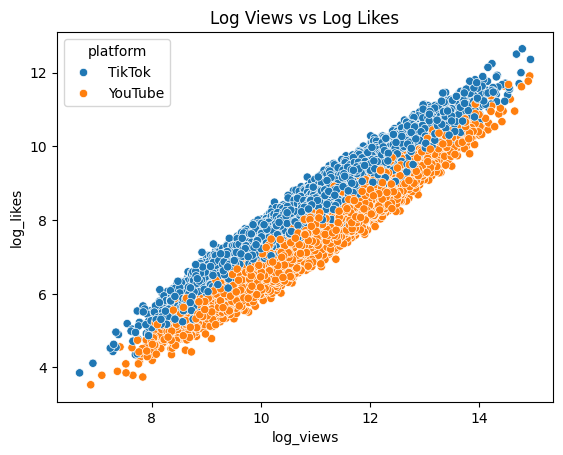

In [54]:
df["log_views"] = np.log1p(df["views"])
df["log_likes"] = np.log1p(df["likes"])

sns.scatterplot(data=df, x="log_views", y="log_likes", hue="platform")
plt.title("Log Views vs Log Likes")
plt.show()

Ao analisar a relação entre visualizações e likes por plataforma, observa-se que vídeos do Tiktok apresentam consistentemente mais likes do que vídeos do YouTube Shorts para o mesmo número de visualizações.

Isso sugere que o TikTok possui maior taxa de engajamento por view, possivelmente devido a diferenças no comportamento dos usuários ou no funcionamento dos algoritmos de recomendação.

Esse resultado indica que a variável "platform" é relevante para modelagem e não deve ser ignorada.

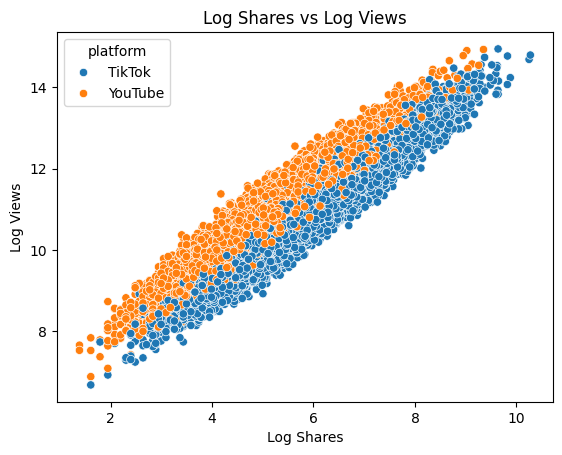

In [55]:
df["log_shares"] = np.log1p(df["shares"])
df["log_views"] = np.log1p(df["views"])

sns.scatterplot(data=df,x="log_shares", y="log_views", hue="platform")
plt.title("Log Shares vs Log Views")
plt.xlabel("Log Shares")
plt.ylabel("Log Views")
plt.show()

A relação entre shares e views apresenta comportamento linear, indicando forte associação entre compartilhamentos e alcance.

No entanto, observa-se uma diferença relevante entre plataformas: vídeos do YouTube Shorts apresentam mais visualizações para a mesma quantidade de shares quando comparadas ao TikTok.

Isso sugere que compartilhamentos possuem maior impacto na distribuição de conteúdo no Youtube, enquanto no TikTok outras métricas como likes, visto anteriormente, podem ter maior relevância.

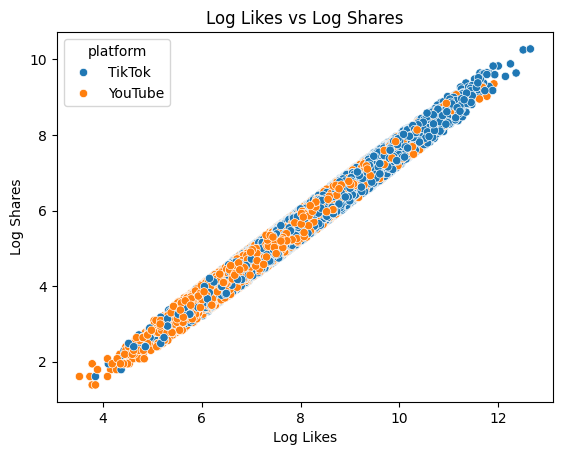

In [56]:
sns.scatterplot(data=df, x="log_likes", y="log_shares", hue="platform")
plt.title("Log Likes vs Log Shares")
plt.xlabel("Log Likes")
plt.ylabel("Log Shares")
plt.show()

O gráfico acima releva uma correlação linear fortíssima, indicando redundância entre as métricas de engajamento. Para a modelagem, manter ambas as bariáveis causaria problemas de multicolinearidade, que serão analisados posteriormente.

### Comparação entre plataformas

Objetivo: entender como as métricas se comportam nas diferentes plataformas

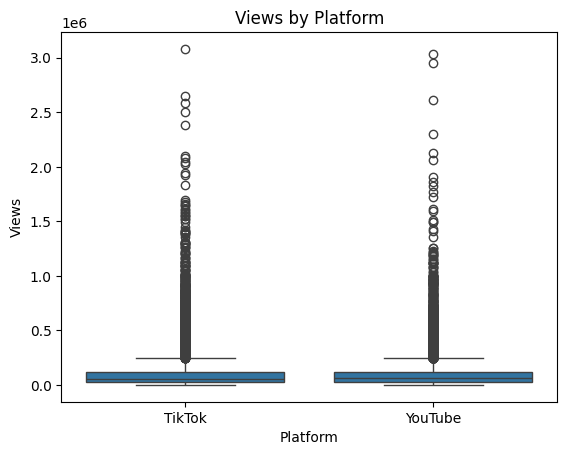

In [57]:
sns.boxplot(data=df, x="platform", y="views")
plt.title("Views by Platform")
plt.xlabel("Platform")
plt.ylabel("Views")
plt.show()

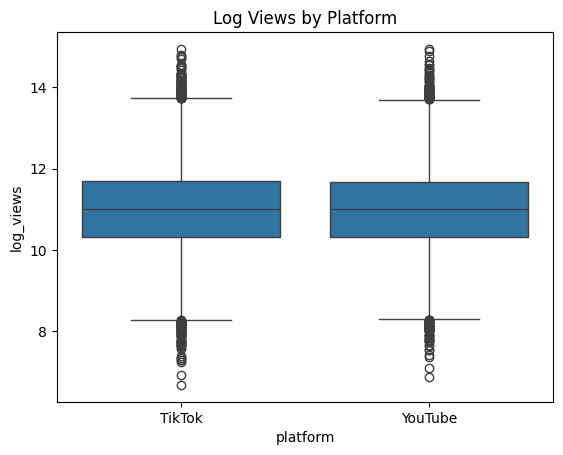

In [58]:
df["log_views"] = np.log1p(df["views"])

sns.boxplot(data=df, x="platform", y="log_views")
plt.title("Log Views by Platform")
plt.show()

A distribuição de visualizações entre Tiktok e Youtube Shorts é bastante semelhante, com medianas e intervalos interquartis próximos.

Ambas as plataformas apresentam grande quantidade de outliers, indicando que videos virais ocorrem em ambos os ambientes.

Isso sugere que o potencial de alcance é similar entre plataformas, enquanto diferenças observadas anteriormente em métricas de engajamento (como likes e shares) podem estar mais relacionadas ao comportamento do usuário do que ao volume bruto de visualizações.

### Conteúdo

Objetivo: entender como as métricas associadas ao vídeo inicialmente influenciam nas visualizações

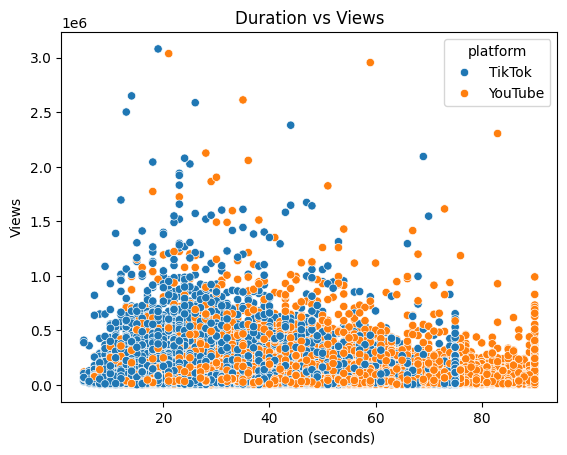

In [59]:
sns.scatterplot(data=df, x="duration_sec", y="views", hue="platform")
plt.title("Duration vs Views")
plt.xlabel("Duration (seconds)")
plt.ylabel("Views")
plt.show()

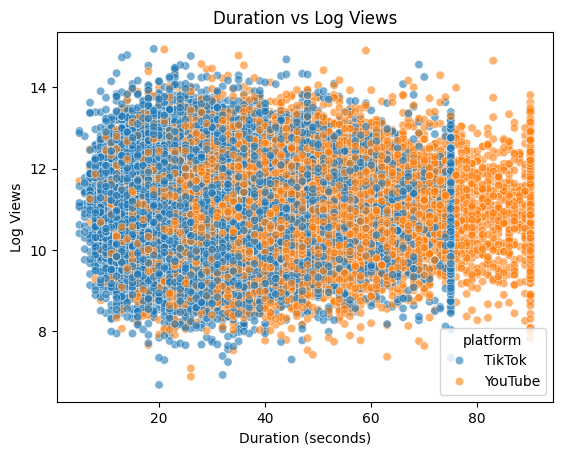

In [60]:
sns.scatterplot(data=df, x="duration_sec", y="log_views", hue="platform", alpha=0.6)
plt.title("Duration vs Log Views")
plt.xlabel("Duration (seconds)")
plt.ylabel("Log Views")
plt.show()

A relação entre duração do vídeo e número de visualizaões não apresenta correlação clara, indicando que a duração isoladamente não é um fator determinante para viralização.

Pode-se observar alta variabilidade de desempenho para praticamente todas as faixas de duração, sugerindo que outros fatores, como engajamento e retêncão, tem maior influência.

Além disso, vídeos mais longos não demonstram vantagem consistente em termos de visualização, reforçando a importância de métricas qualitativas em detrimento do tempo bruto de conteúdo.

In [61]:
df["duration_bucket"] = pd.cut(df["duration_sec"], bins=[0, 15, 30, 60, 120], 
                               labels=["0-15s", "15-30s", "30-60s", "60s+"])


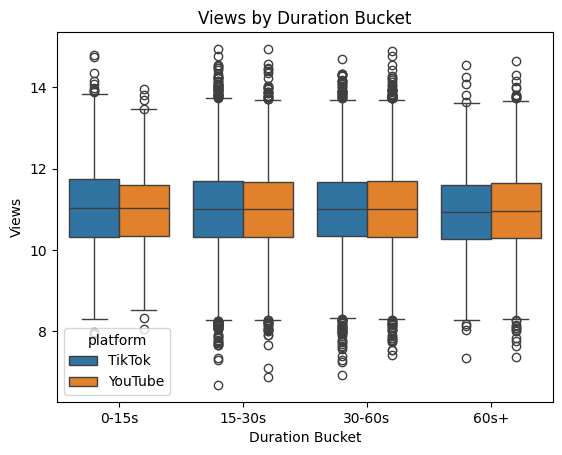

In [62]:
sns.boxplot(data=df, x="duration_bucket", y="log_views", hue="platform")
plt.title("Views by Duration Bucket")
plt.xlabel("Duration Bucket")
plt.ylabel("Views")
plt.show()

A variável de duração foi discretizada em faixas (buckets) para facilitar a analise de padrões de desempenho por intervalo de tempo.

Essa abordagem permite identificar comportamentos que são mais difíceis de visualizar na variável contínua.

Apesar disso, a análise permanece a mesma que a anterior.

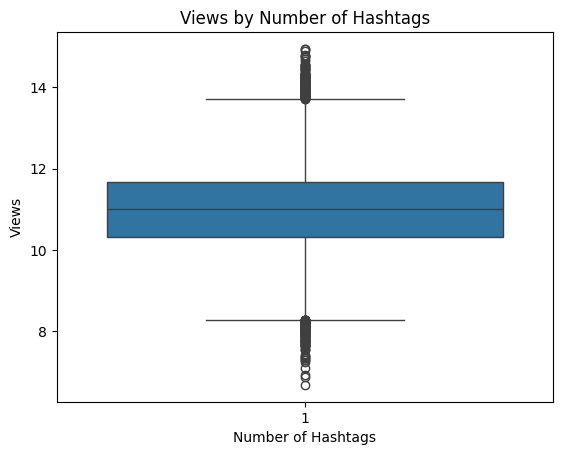

In [63]:
df["num_hashtags"] = df["hashtag"].apply(lambda x: len(str(x).split()))
sns.boxplot(data=df, x="num_hashtags", y="log_views")
plt.title("Views by Number of Hashtags")
plt.xlabel("Number of Hashtags")
plt.ylabel("Views")
plt.show()

A variável relacionada a hashtags não apresenta variação significativa no dataset (apenas uma hashtag principal é disponibilizada), o que impede a análise de influência de hashtags combinadas no número de visualizações.

Ainda assim, podemos analisar quais hashtags estão mais presentes nos vídeos virais.

In [64]:
top_df = df[df["views"] > df["views"].quantile(0.9)]
top_hashtags = top_df["hashtag"].value_counts().head(10)
print(top_hashtags)

hashtag
#FYP               1191
#GRWM               183
#Lifestyle          132
#Music              130
#Relatable          120
#Cover              118
#Comedy             118
#MorningRoutine     114
#DanceChallenge     112
#AI                 112
Name: count, dtype: int64


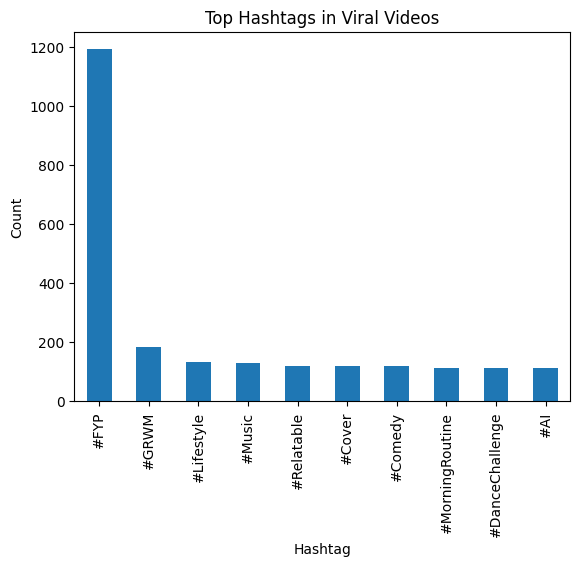

In [65]:
top_hashtags.plot(kind="bar")
plt.title("Top Hashtags in Viral Videos")
plt.xlabel("Hashtag")
plt.ylabel("Count")
plt.show()

Um ponto relevante é que as hashtags mais usadas e relevantes podem mudar dependendo da plataforma, então pode ser interessante separar esse ranking por plataforma.

In [66]:
tiktok_top = (
    top_df[top_df["platform"] == "TikTok"]["hashtag"]
    .value_counts()
    .head(10)
)

youtube_top = (
    top_df[top_df["platform"] == "YouTube"]["hashtag"]
    .value_counts()
    .head(10)
)

print("TikTok:\n", tiktok_top)
print("\nYouTube:\n", youtube_top)

TikTok:
 hashtag
#FYP               719
#GRWM              125
#Lifestyle          82
#Comedy             73
#DanceChallenge     72
#Music              71
#MorningRoutine     71
#AI                 70
#Relatable          69
#Sports             66
Name: count, dtype: int64

YouTube:
 hashtag
#FYP            472
#Music           59
#GRWM            58
#Cover           52
#Dance           52
#Relatable       51
#Lifestyle       50
#OOTD            48
#Comedy          45
#StudyWithMe     45
Name: count, dtype: int64


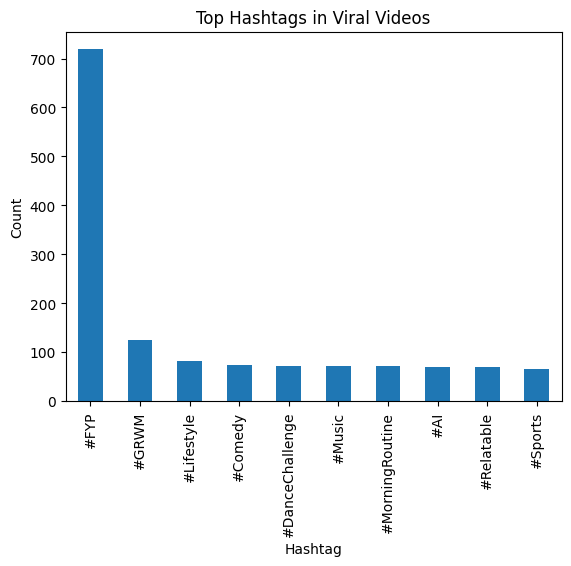

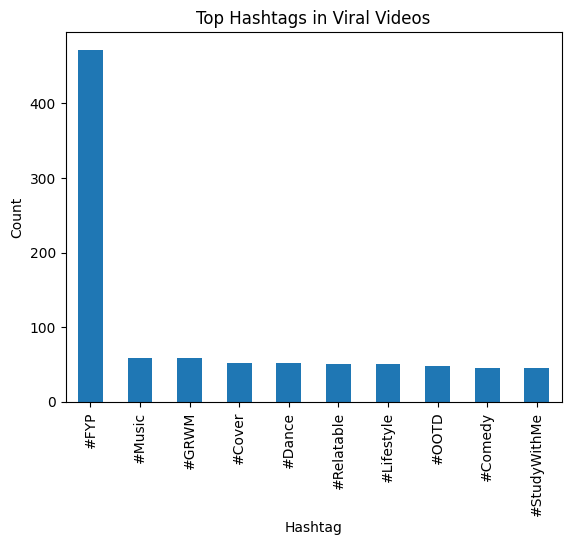

In [67]:
tiktok_top.plot(kind="bar")
plt.title("Top Hashtags in Viral Videos")
plt.xlabel("Hashtag")
plt.ylabel("Count")
plt.show()

youtube_top.plot(kind="bar")
plt.title("Top Hashtags in Viral Videos")
plt.xlabel("Hashtag")
plt.ylabel("Count")
plt.show()

A análise das hashtags em vídeos virais mostra uma sobreposição significativa entre TikTok e Youtube Shorts, com destaque para hashtags genéricas como #FYP e #Music.

No entanto, observam-se diferenças relevantes:

- TikTok apresenta maior presença de hashtags associadas a tendências e rotinas pessoas, como #GRWM, #MorningRoutine e #DanceChallenge.
- Youtube Shorts apresenta maior frequência de conteúdos mais estruturados e de nicho, como #Cover, #StudyWithMe e #OOTD.

Esses padrões sugerem diferenças no comportamento dos criadores e no tipo de conteúdo predomintante em cada plataforma.

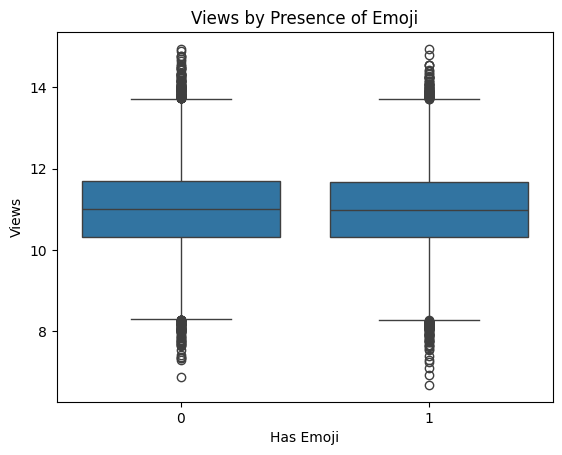

In [68]:
sns.boxplot(data=df, x="has_emoji", y="log_views")
plt.title("Views by Presence of Emoji")
plt.xlabel("Has Emoji")
plt.ylabel("Views")
plt.show()

### Tempo

Objetivo: entender como as métricas associadas a quando o vídeo é publicado influenciam nas visualizações

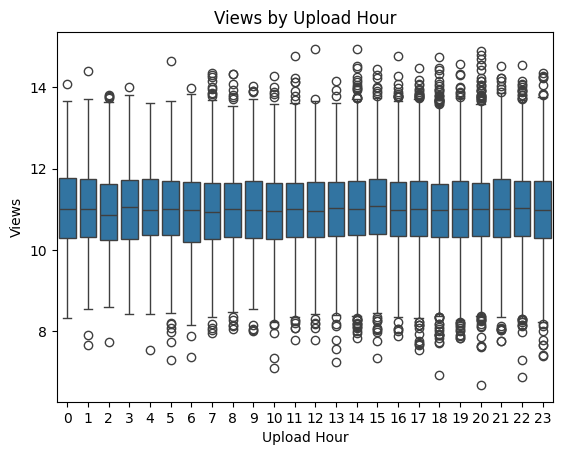

In [69]:
sns.boxplot(data=df, x="upload_hour", y="log_views")
plt.title("Views by Upload Hour")
plt.xlabel("Upload Hour")
plt.ylabel("Views")
plt.show()

A análise da relação entre horário de upload e número de visualizações não apresenta diferenças significativas entre os períodos do dia.

Embora existam variações pontuais e presença de outliers em diversos horários, não é possível identificar através desse gráfico um padrão consistente que indique um horário ideal para maximizar visualizações.

Isso pode sugerir que o horário de publicação, isoladamente, não é um fator determinante para a viralização de vídeos.

In [70]:
df["period"] = pd.cut(df["upload_hour"], bins=[0,6, 12, 18, 24], 
                               labels=["0-6h", "6-12h", "12-18h", "18-24h"])

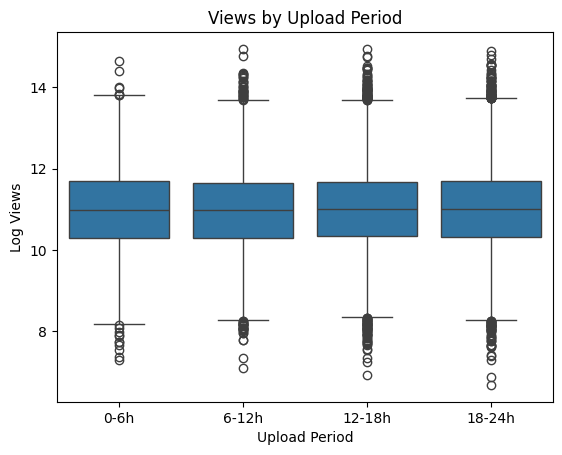

In [71]:
sns.boxplot(data=df, x="period", y="log_views")
plt.title("Views by Upload Period")
plt.xlabel("Upload Period")
plt.ylabel("Log Views")
plt.show()

Ao agrupar os horários de postagem em períodos do dia, observa-se que a distribuição de visualizações permanece bastante semelhante entre os grupos.

Embora haja uma leve tendência de maior dispersão e presença de outliers nos períodos da tarde e noite, essa diferença continua não sendo suficientemente significativa para indicar um impacto forte do horário de publicação.

Dessa forma, o período de upload parece ter influência limitada no desempenho vídeos quando analisado isoladamente.

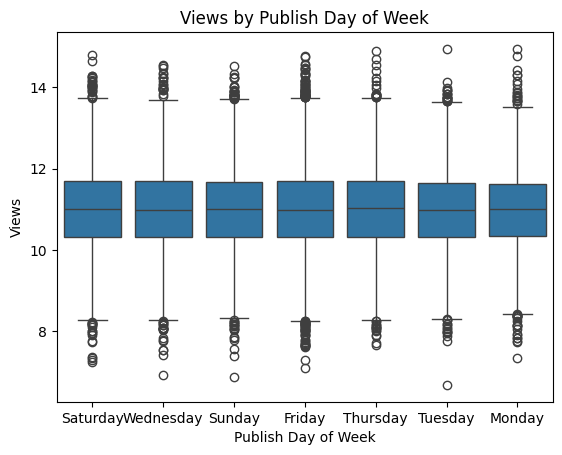

In [ ]:
sns.boxplot(data=df, x="publish_dayofweek", y="log_views")
plt.title("Views by Publish Day of Week")
plt.xlabel("Publish Day of Week")
plt.ylabel("Views")
plt.show()

A análise da relação entre views e o dia da semana da postagem aparentemente não nos traz algo muito interessante.

A presença de vídeos virais virais é constante de segunda a domingo, reforçando ainda mais que o algoritmo não prioriza o momento da publicação.

### Métricas Avançadas

Objetivo: buscar e entender métricas mais complexas associadas ao vídeos que influenciam nas visualizações

Algumas métricas aparentam estar mais associadas a viralização dos vídeos, assim, vamos focar a análise nelas e em suas relações.

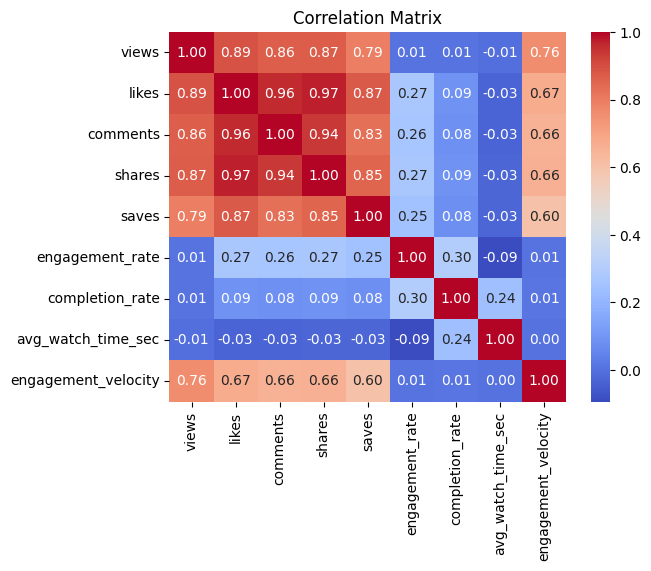

In [73]:
cols = [
    "views", "likes", "comments", "shares", "saves",
    "engagement_rate", "completion_rate",
    "avg_watch_time_sec", "engagement_velocity"
]

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

A partir da matriz de correlação, podemos extrair alguns insights:

- As variáveis *views*, *likes*, *comments*, *shares* e *saves* possuem correlações altíssimas (entre 0.79 e 0.97), evidenciando que elas são reduntantes, já que é natutal que um vídeo com muitas views tenha mais likes e shares. Usar todas elas para prever pode causar multicolinearidade, confundindo o modelo.

- A correlação entre *completion_rate* e *views* é de apenas 0.01, quebrando uma ideia comum de que quanto mais retenção, mais views de forma linear. Assim, a relação pode ser não-linear.

- A correlação de *engagement_velocity* com *views* é de 0.76, sendo essa a métrica mais forte fora as métricas "brutas", podendo evidenciar que o algoritmo não olha apenas o engamento que um perfil tem, mas o quão rápido ele acontece.

- A correlação entre *avg_watch_time_sec* e *completion_rate* é baixa (0.24). As plataformas parecem equilibrar as duas coisas. O Youtube Shorts tende a valorizar o tempo total, enquanto o TikTok foca na conclusão e repetição.

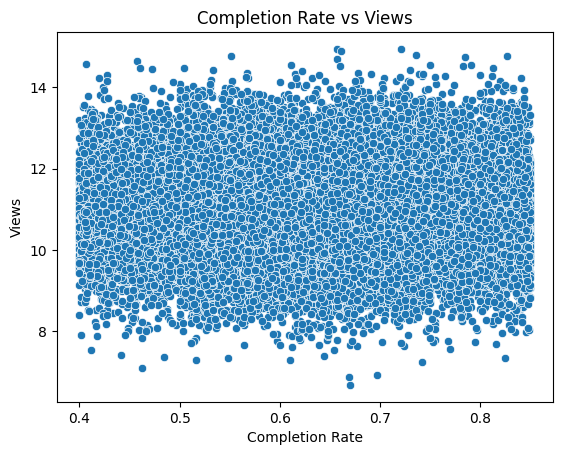

In [74]:
sns.scatterplot(data=df, x="completion_rate", y="log_views")
plt.title("Completion Rate vs Views")
plt.xlabel("Completion Rate")
plt.ylabel("Views")
plt.show()

Diferente da crença popular de criadores de conteúdo, *completion rate* apresenta uma correlação quase nula com o volume total de vires. Isso indica que, embora a retenção seja necessária para manter o usuário na plataforma, o "impulso" de distribuição em massa (viralização) é ditado por outros sinais, possivelmente ligados ao compartilhamento e à velocidade de interação inicial.

#### A retenção importa para os "Top 10%?"
Vamos comparar a distribuição de rentenção entre vídeoss virais e vídeos comuns

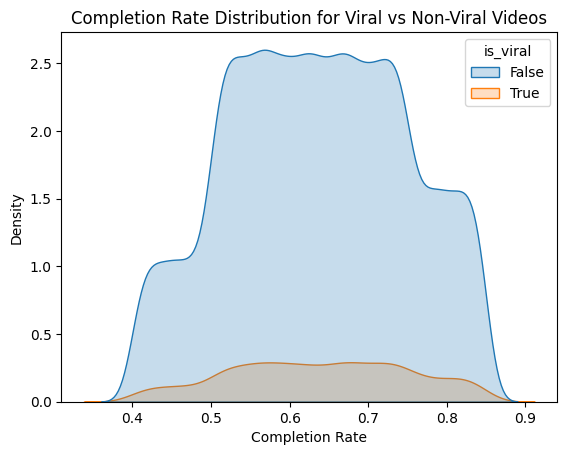

In [75]:
df["is_viral"] = df["views"] > df["views"].quantile(0.9)

sns.kdeplot(data=df, x="completion_rate", hue="is_viral", fill=True)
plt.title("Completion Rate Distribution for Viral vs Non-Viral Videos")
plt.xlabel("Completion Rate")
plt.ylabel("Density")
plt.show()

Através deste gráfico de densidade, é possível confirmar o que a correlação de 0.01 já mostrava: a retenção não é o diferencial competitivo para a viralização, pelo menos, no conjunto de dados analisado.

Mas há algo interessante que podemos notar: ambas as distribuições começão a subir significativamente após os 45%. Isso sugere que a retenção atua mais como um *pré-requisito básico* do que como um *fator de impulsionamento*. Se o vídeo não tem o mínimo de retenção, ele nem é considerado, mas ter retenção alta não garante viralização.

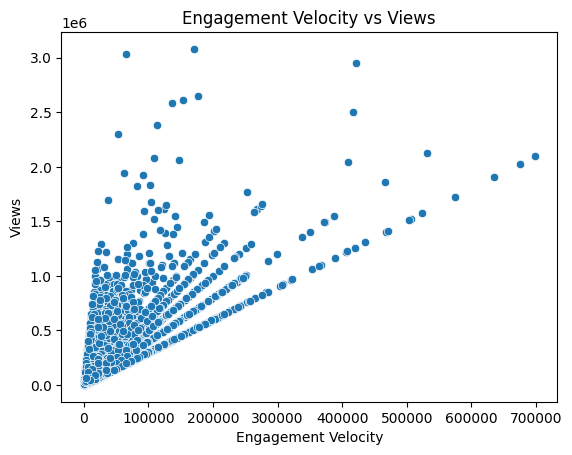

In [76]:
sns.scatterplot(data=df, x="engagement_velocity", y="views")
plt.title("Engagement Velocity vs Views")
plt.xlabel("Engagement Velocity")
plt.ylabel("Views")
plt.show()

Podemos notar uma estrutura de "leque" (Fan Pattern), indicando que a velocidade de engajamento atua como um *limitador de teto*. Assim, é quase impossível ter milhões de views sem uma alta velocidade de engajamento inicial.

Conforme a velocidade aumenta, a dispersão pra cima também aumenta. Isso sugere que a velocidade "abre a porta" para a viralização, mas outros fatores (como compartilhamentos ou até sorte algorítimica) decidem o quão alto o vídeo vai chegar

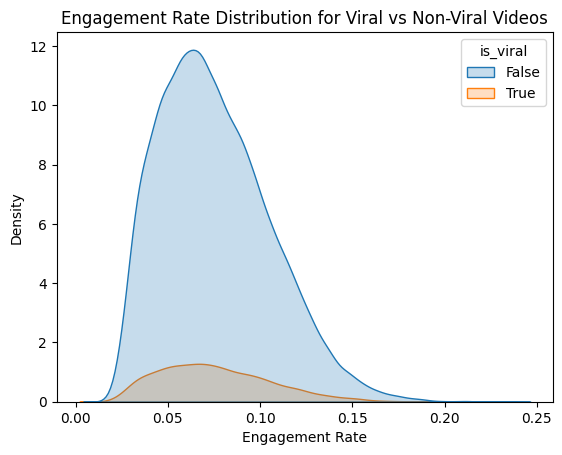

In [77]:
sns.kdeplot(data=df, x="engagement_rate", hue="is_viral", fill=True)
plt.title("Engagement Rate Distribution for Viral vs Non-Viral Videos")
plt.xlabel("Engagement Rate")
plt.ylabel("Density")
plt.show()

Já no gráfico de densidade, podemos notar que a curva de vídeos virais é mais "achatada", evidenciando que, enquanto vídeos comuns morrem rapidamente após cerca 7% de engagement rate, os vídeos virais tem uma presença mais forte em taxas de engajamento mais altas (10% a 15%).

Assim, um *engagement_rate* alto é um sinal mais confiável de um vídeo viral do que uma retenção alta.

## Conclusões da Análise Exploratória

Após a análise de cerca de 48 mil registros, podemos responder as perguntas norteadores do projeto e adicionar camadas mais profundas de entendimento:

#### O que mais impacta views?

A resposta: A *Velocidade de Engajamento* (*engagement_velocity*).

Diferente de métricas estáticas, a rapidez com que o público interage nos primeiros minutos/horas é o maior preditor de alcance. Existe um padrão de "leque" onde altas velocidades "abrem a porta" para milhões de visualizações, enquando baixas velocidades limitam o teto do vídeo.

*Likes* e *Shares* tem correlação altíssima com views (0.85+), mas são consequências, não causas. Para o modelo, usaremos *taxas de eficiência* para evitar vazamento de dados.

#### Retenção importa?

A resposta: Sim, mas não como se imaginava inicialmente.

A correlação entre **completion_rate** e **views** é quase nula. O gráfico de densidade mostrou que vídeos virais e não-virais possuem distribuições de retenção quase idênticas.

A retenção parece ser um **pré-requisito**. Se o vídeo tem menos de 45% de retenção, ele raramente performa, mas ter 80% não  garante a viralização. A retenção "matém o vídeo vivo", mas o engajamento ativo é o que faz o vídeo disparar.

#### Existe horário ou dia ideal?

A resposta: Não de forma significativa.

Os boxplots por **upload_hour** e **publish_dayofweek** mostraram medianas de visualizações constantes. Outliers (virais) acontecem em qualquer horário.

Estratégias baseadas estritamente em "horários nobres" têm impacto insignificante comparado à qualidade do conteúdo e resposta inicial do público.

#### Quais as diferenças entre plataformas?

A resposta: O comportamento de **consumo VS distribuição** varia.

**TikTok** apresenta maior taxa de **Likes por View**, indicando uma comunidade mais propensa à interação rápida e apreciação.

**YouTube Shorts** mostrou-se mais eficiente na relação **Shares por View**, sugerindo que o conteúdo do YouTube tende a ser mais "compartilhável" ou distribuído por links externos

Em relação ao conteúdo, TikTok foca em tendências de rotida (#GRWM), enquanto YouTube foca em conteúdos estruturados (#StudyWhitMe).

#### Perguntas adicionais

Durante a limpeza e análise, surgiram pontos fundamentais que o modelo de ML precisará considerar:

**O engajamento é redundante?**

Resposta: Sim, o gráfico que mostra a relação entre **Likes** e **Shares** mostrou uma linha reta quase perfeita. Para o modelo, não precisamos de ambos, escolheremos um (ou uma taxa combinada dos dois) para simplificar o aprendizado e evitar multicolinearidade.

**A duração do vídeo dita o sucesso?**

Resposta: Não isoladamente. Vídeos de todas as faixas (0-15s até 60s+) atingem o topo. O que importa é a **densidade de engajamento** dentro dessa duração, e não o tempo bruto.

**Emojis e Hashtags influenciam?**

Resposta: Emojis tem impacto visual, mas as hashtags funcionam como **indexadores de nicho**. Vídeos virais do TikTok usam hashtags de "comunidade", enquanto no YouTube funcionam mais como "categorias de busca".